In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from classifier_selector import Classifier_selector
import joblib

In [2]:
from pandas import DataFrame

def pretty_print_classification_report(report_dict):
    # Extract the metrics we care about
    classes_data = {k: v for k, v in report_dict.items()
                   if k not in ['accuracy', 'macro avg', 'weighted avg']}

    # Create a DataFrame for the classes
    class_df = DataFrame(classes_data).T

    # Create a DataFrame for the averages
    avg_data = {k: v for k, v in report_dict.items()
               if k in ['macro avg', 'weighted avg']}
    avg_df = DataFrame(avg_data).T

    # Format precision, recall, and f1-score to 3 decimal places
    for df in [class_df, avg_df]:
        for col in ['precision', 'recall', 'f1-score']:
            if col in df.columns:
                df[col] = df[col].map('{:.5f}'.format)


    print("\n===== Classification Performance Report =====")
    print("\nPer-Class Performance:")
    print(class_df)
    print("\nOverall Performance:")
    print(avg_df)


    if 'accuracy' in report_dict:
        print(f"\nAccuracy: {report_dict['accuracy']:.3f}")

In [3]:
X_positives = pd.read_csv("./cpp_positive_training_aac.csv")
X_negatives = pd.read_csv("./cpp_negative_training_aac.csv")
y_positives = np.ones(len(X_positives))
y_negatives = np.zeros(len(X_negatives))

In [4]:
# Verifying shapes

print(X_positives.shape)
print(X_negatives.shape)
print(y_positives.shape)
print(y_negatives.shape)

(573, 20)
(573, 20)
(573,)
(573,)


In [5]:
frames = [X_positives, X_negatives]
X = pd.concat(frames)
print(X.shape)

(1146, 20)


In [6]:
y = np.concatenate((y_positives, y_negatives), axis = None)
print(y.shape)

(1146,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True)

In [8]:
cs = Classifier_selector()

n_jobs = 2
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'degree': 2, 'coef0': 0.0, 'class_weight': 'balanced', 'C': 10}

Best Cross-validation Score: 0.8519563817312699

Feature Importances: None

Classification Report:

===== Classification Performance Report =====

Per-Class Performance:
    precision   recall f1-score  support
0.0   0.86260  0.91129  0.88627    124.0
1.0   0.88889  0.83019  0.85854    106.0

Overall Performance:
             precision   recall f1-score  support
macro avg      0.87574  0.87074  0.87241    230.0
weighted avg   0.87471  0.87391  0.87349    230.0

Accuracy: 0.874


['best_svm_model.pkl']

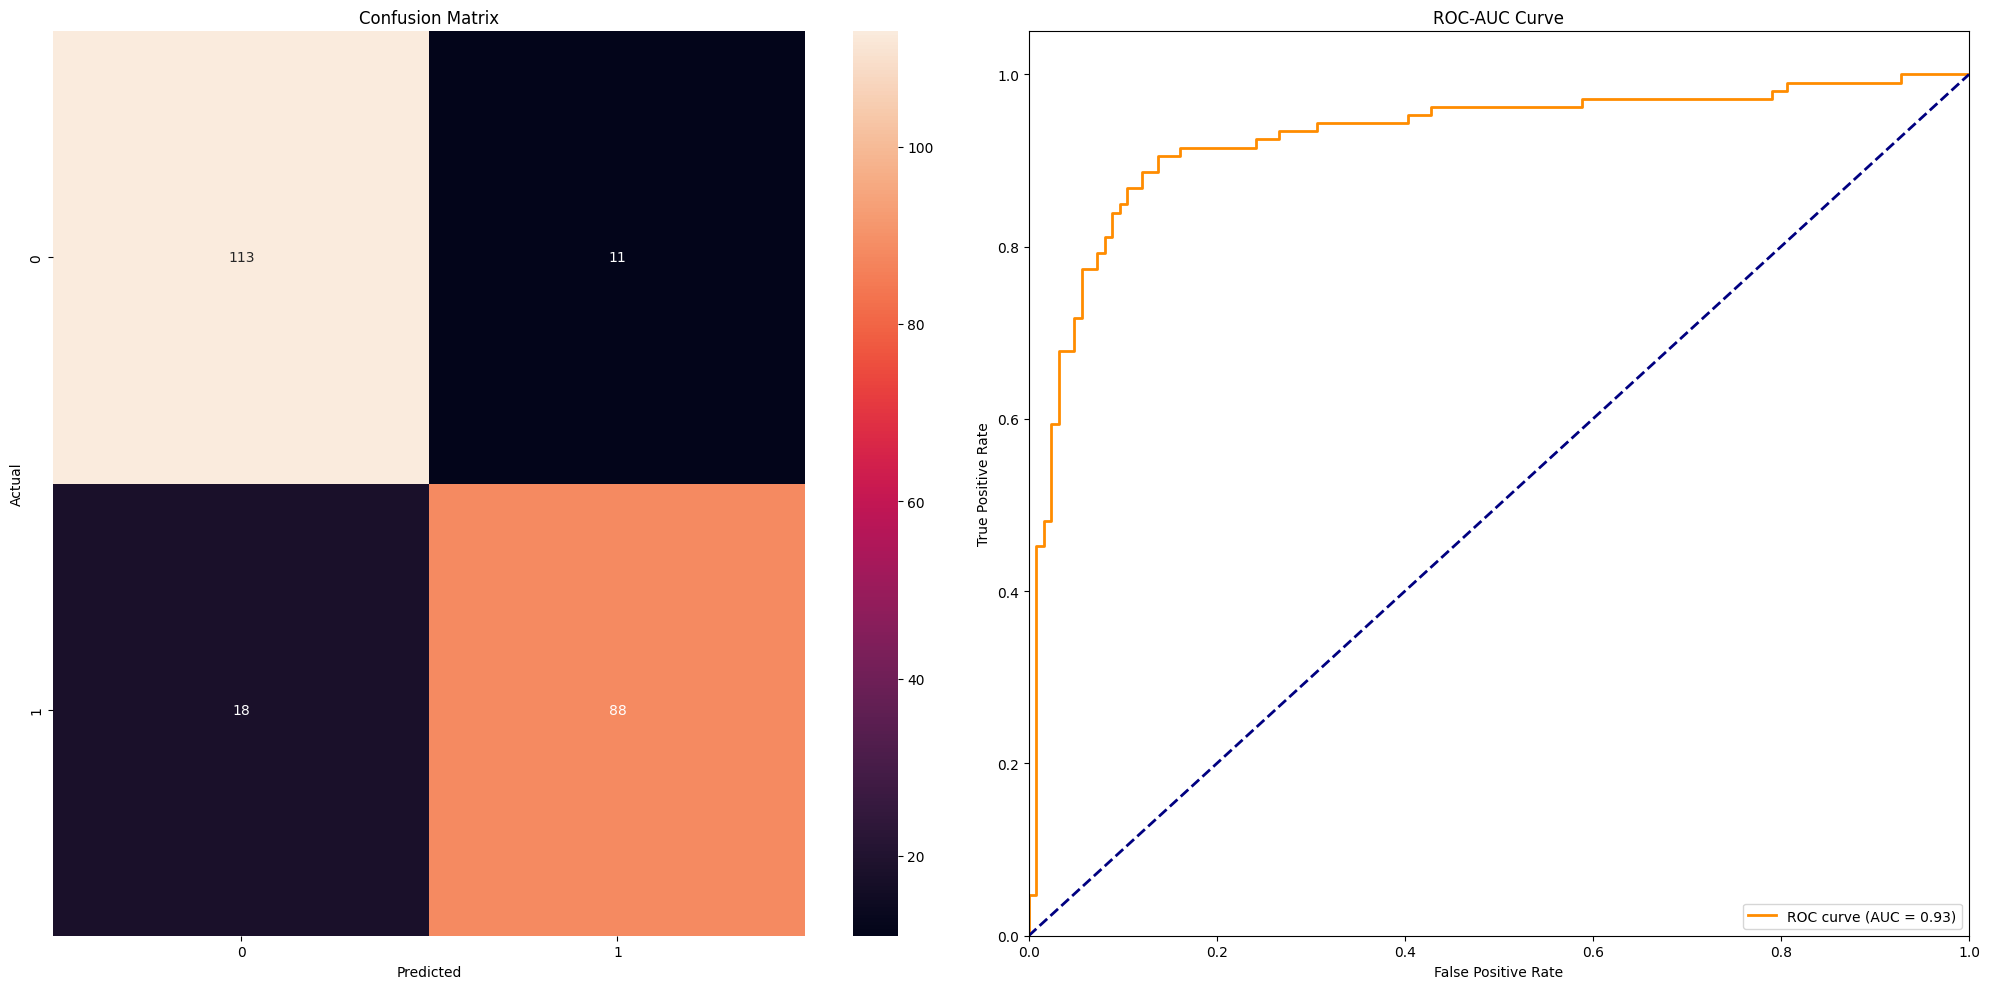

In [9]:
results_svm = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'svm')

print("\nBest Parameters:", results_svm['best_parameters'])
print("\nBest Cross-validation Score:", results_svm['best_score'])
print("\nFeature Importances:", results_svm['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_svm['classification_report'])

joblib.dump(results_svm['best_model'], 'best_svm_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

Best Cross-validation Score: 0.8785767167611258

Feature Importances: None

Classification Report:

===== Classification Performance Report =====

Per-Class Performance:
    precision   recall f1-score  support
0.0   0.88034  0.83065  0.85477    124.0
1.0   0.81416  0.86792  0.84018    106.0

Overall Performance:
             precision   recall f1-score  support
macro avg      0.84725  0.84928  0.84748    230.0
weighted avg   0.84984  0.84783  0.84805    230.0

Accuracy: 0.848


['best_knn_model.pkl']

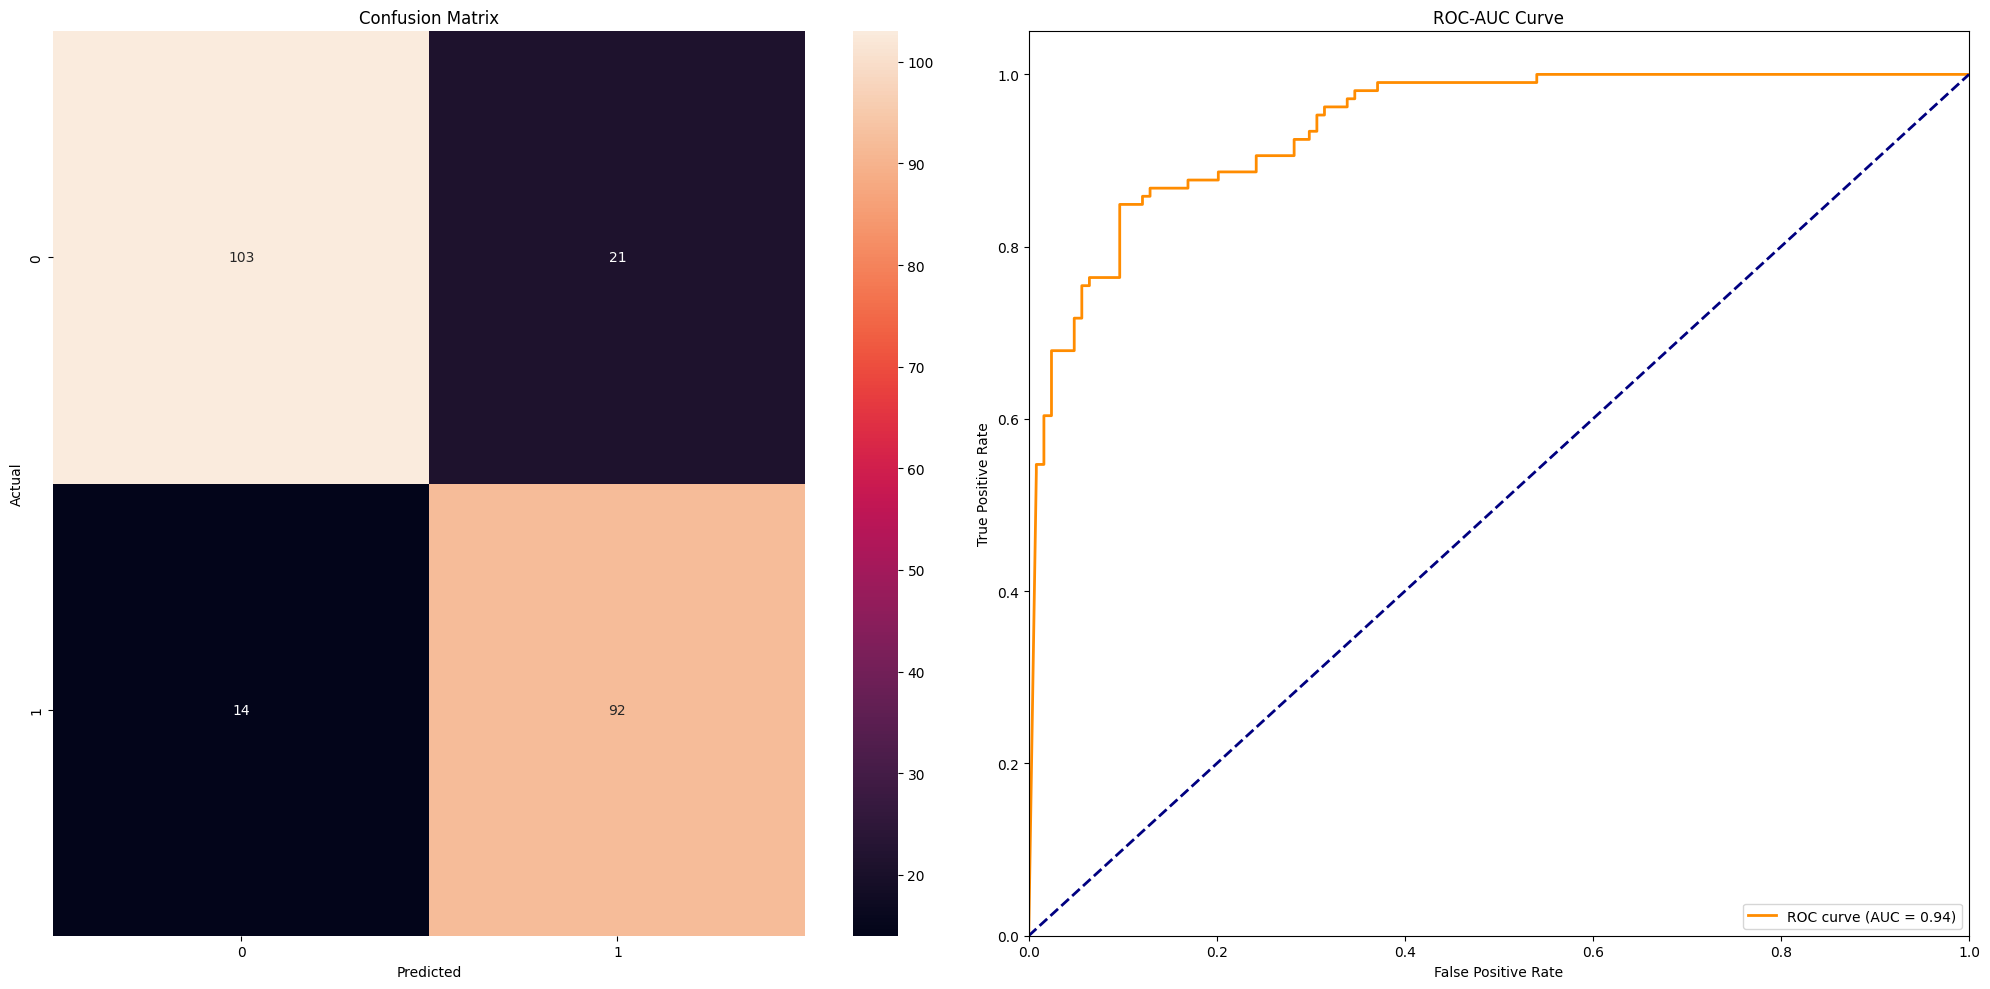

In [10]:
results_knn = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'knn')

print("\nBest Parameters:", results_knn['best_parameters'])
print("\nBest Cross-validation Score:", results_knn['best_score'])
print("\nFeature Importances:", results_knn['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_knn['classification_report'])

joblib.dump(results_knn['best_model'], 'best_knn_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 48 candidates, totalling 240 fits


/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 48 is smaller than n_iter=100. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters: {'validation_fraction': 0.1, 'tol': 0.001, 'penalty': 'l1', 'max_iter': 500, 'early_stopping': True, 'alpha': 0.0001}

Best Cross-validation Score: 0.7577144847920818

Feature Importances: {'AAC_A': 4.967725808320822, 'AAC_C': 0.10406873099935443, 'AAC_D': 0.26800977091449196, 'AAC_E': 1.1435206882478854, 'AAC_F': 0.8744223552927736, 'AAC_G': 1.9654300504517903, 'AAC_H': 4.34765212121976, 'AAC_I': 0.3438063959708072, 'AAC_K': 2.947324383620581, 'AAC_L': 2.492643746027679, 'AAC_M': 3.741131196085398, 'AAC_N': 2.8655935402254964, 'AAC_P': 2.011913833318821, 'AAC_Q': 1.4204597960089325, 'AAC_R': 5.573270781439933, 'AAC_S': 0.0, 'AAC_T': 6.424805804709262, 'AAC_V': 1.2051343085884256, 'AAC_W': 4.009724410301242, 'AAC_Y': 3.8479461971280577}

Classification Report:

===== Classification Performance Report =====

Per-Class Performance:
    precision   recall f1-score  support
0.0   0.71765  0.49194  0.58373    124.0
1.0   0.56552  0.77358  0.65339    106.0

Overall Performa

['best_perceptron_model.pkl']

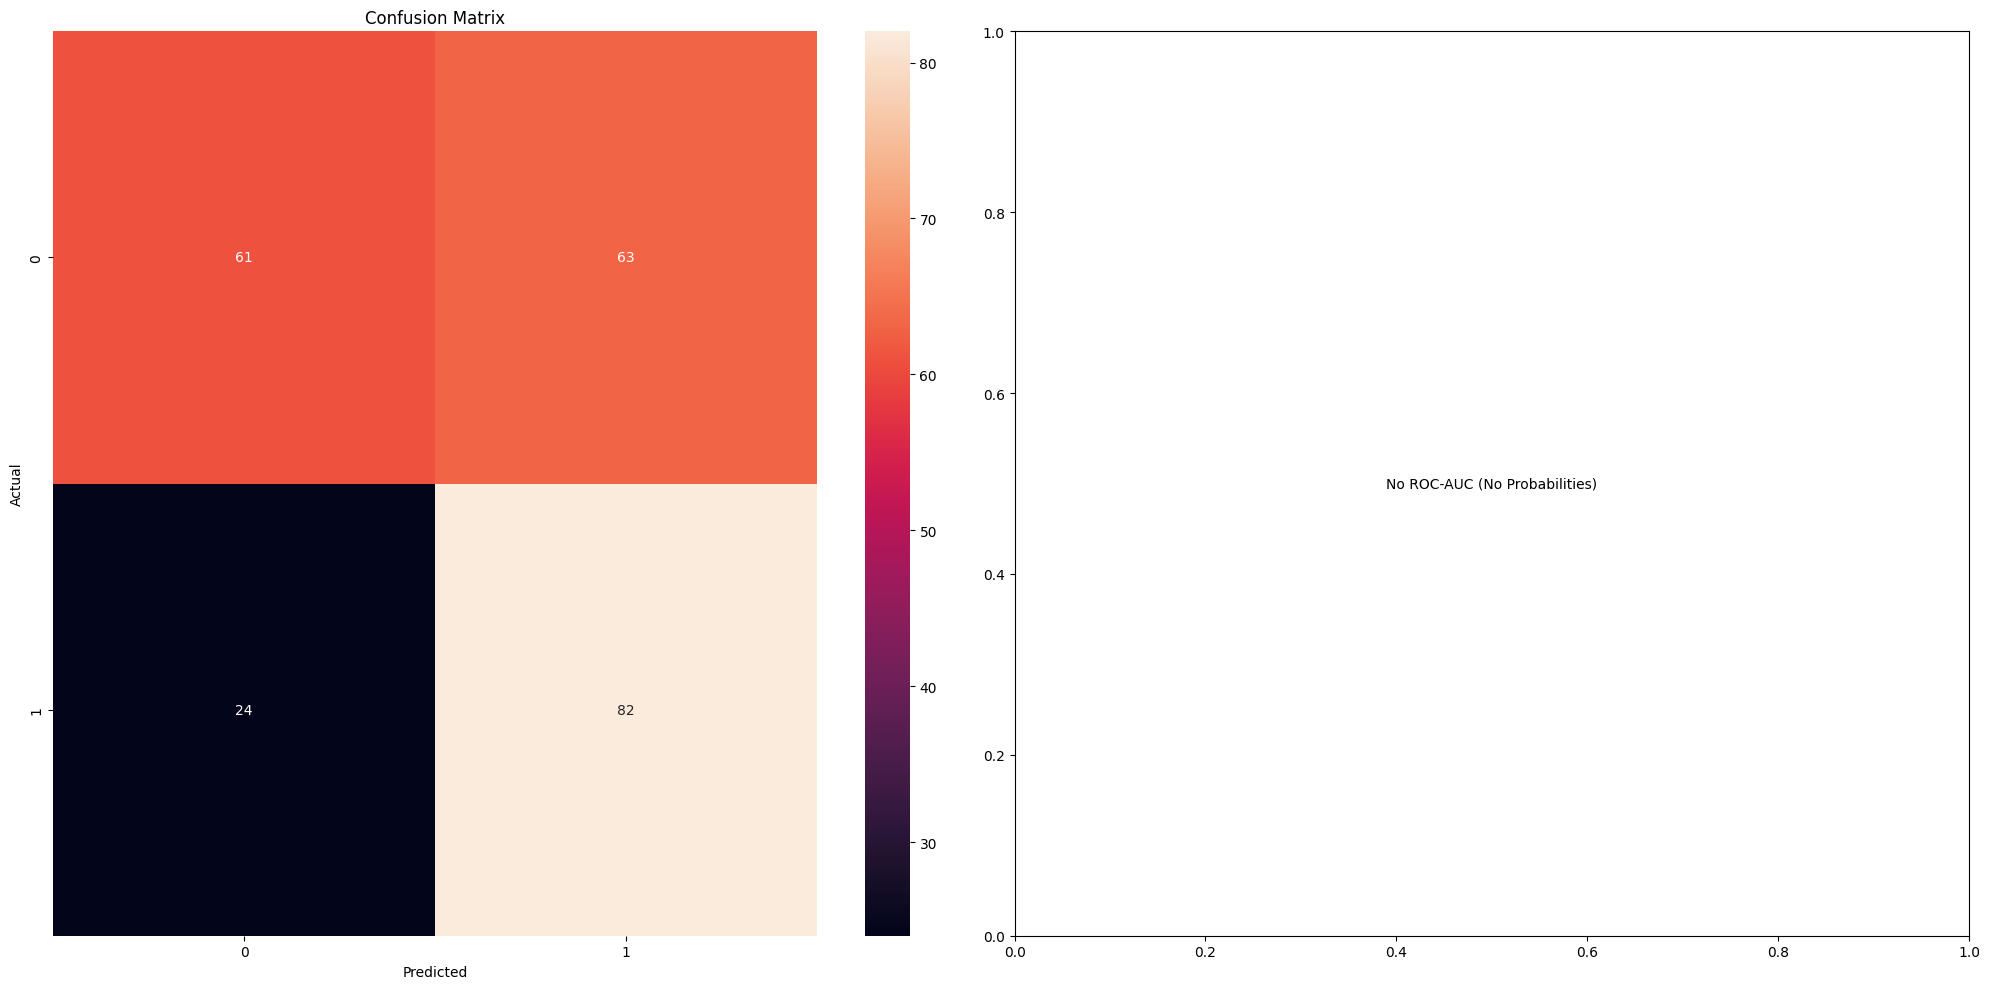

In [11]:
results_perceptron = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'perceptron')

print("\nBest Parameters:", results_perceptron['best_parameters'])
print("\nBest Cross-validation Score:", results_perceptron['best_score'])
print("\nFeature Importances:", results_perceptron['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_perceptron['classification_report'])

joblib.dump(results_perceptron['best_model'], 'best_perceptron_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': True}

Best Cross-validation Score: 0.879242283737429

Feature Importances: {'AAC_A': 0.03305683568096519, 'AAC_C': 0.019313495973189185, 'AAC_D': 0.07369207645917232, 'AAC_E': 0.07272073398698675, 'AAC_F': 0.03970518817822858, 'AAC_G': 0.04091875270852105, 'AAC_H': 0.023910675437038956, 'AAC_I': 0.04262088775667723, 'AAC_K': 0.08087074364548362, 'AAC_L': 0.037577870713350565, 'AAC_M': 0.03221921008501222, 'AAC_N': 0.042493639910960015, 'AAC_P': 0.04560609037730758, 'AAC_Q': 0.023139632937173627, 'AAC_R': 0.19085581337808588, 'AAC_S': 0.03350544602659942, 'AAC_T': 0.032805171294555235, 'AAC_V': 0.08862749410882935, 'AAC_W': 0.02374229797438319, 'AAC_Y': 0.022617943367480152}

Classification Report:

===== Classification Perf

['best_rf_model.pkl']

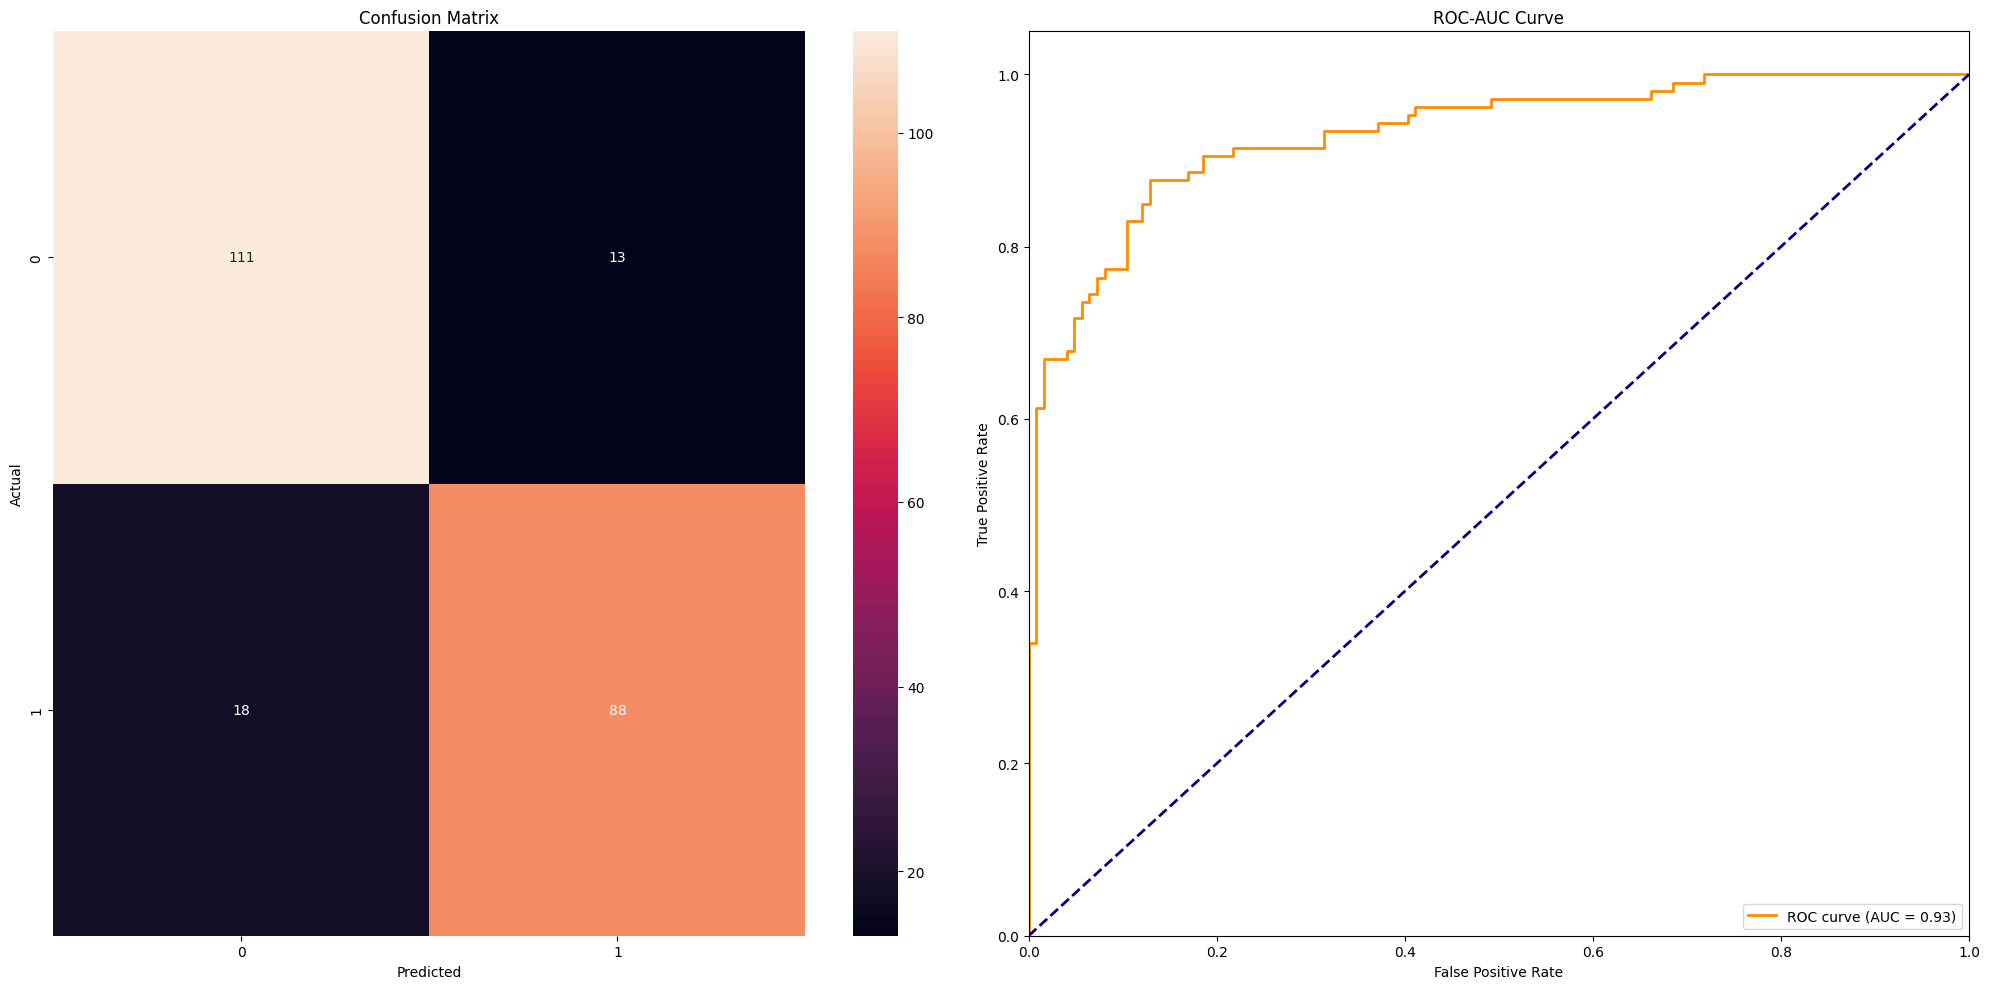

In [12]:
results_rf = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'rf')

print("\nBest Parameters:", results_rf['best_parameters'])
print("\nBest Cross-validation Score:", results_rf['best_score'])
print("\nFeature Importances:", results_rf['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_rf['classification_report'])

joblib.dump(results_rf['best_model'], 'best_rf_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters: {'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 4, 'min_impurity_decrease': 0.01, 'max_features': None, 'max_depth': None, 'criterion': 'gini', 'class_weight': None}

Best Cross-validation Score: 0.8143891962958903

Feature Importances: {'AAC_A': 0.0, 'AAC_C': 0.046059338728468124, 'AAC_D': 0.0, 'AAC_E': 0.10207141537205161, 'AAC_F': 0.0, 'AAC_G': 0.06852115861128848, 'AAC_H': 0.0, 'AAC_I': 0.0, 'AAC_K': 0.23077376385658946, 'AAC_L': 0.0, 'AAC_M': 0.0, 'AAC_N': 0.0, 'AAC_P': 0.0, 'AAC_Q': 0.0, 'AAC_R': 0.5525743234316024, 'AAC_S': 0.0, 'AAC_T': 0.0, 'AAC_V': 0.0, 'AAC_W': 0.0, 'AAC_Y': 0.0}

Classification Report:

===== Classification Performance Report =====

Per-Class Performance:
    precision   recall f1-score  support
0.0   0.78740  0.80645  0.79681    124.0
1.0   0.76699  0.74528  0.75598    106.0

Overall Performance:
             precision   recall f1-score  support
mac

['best_dt_model.pkl']

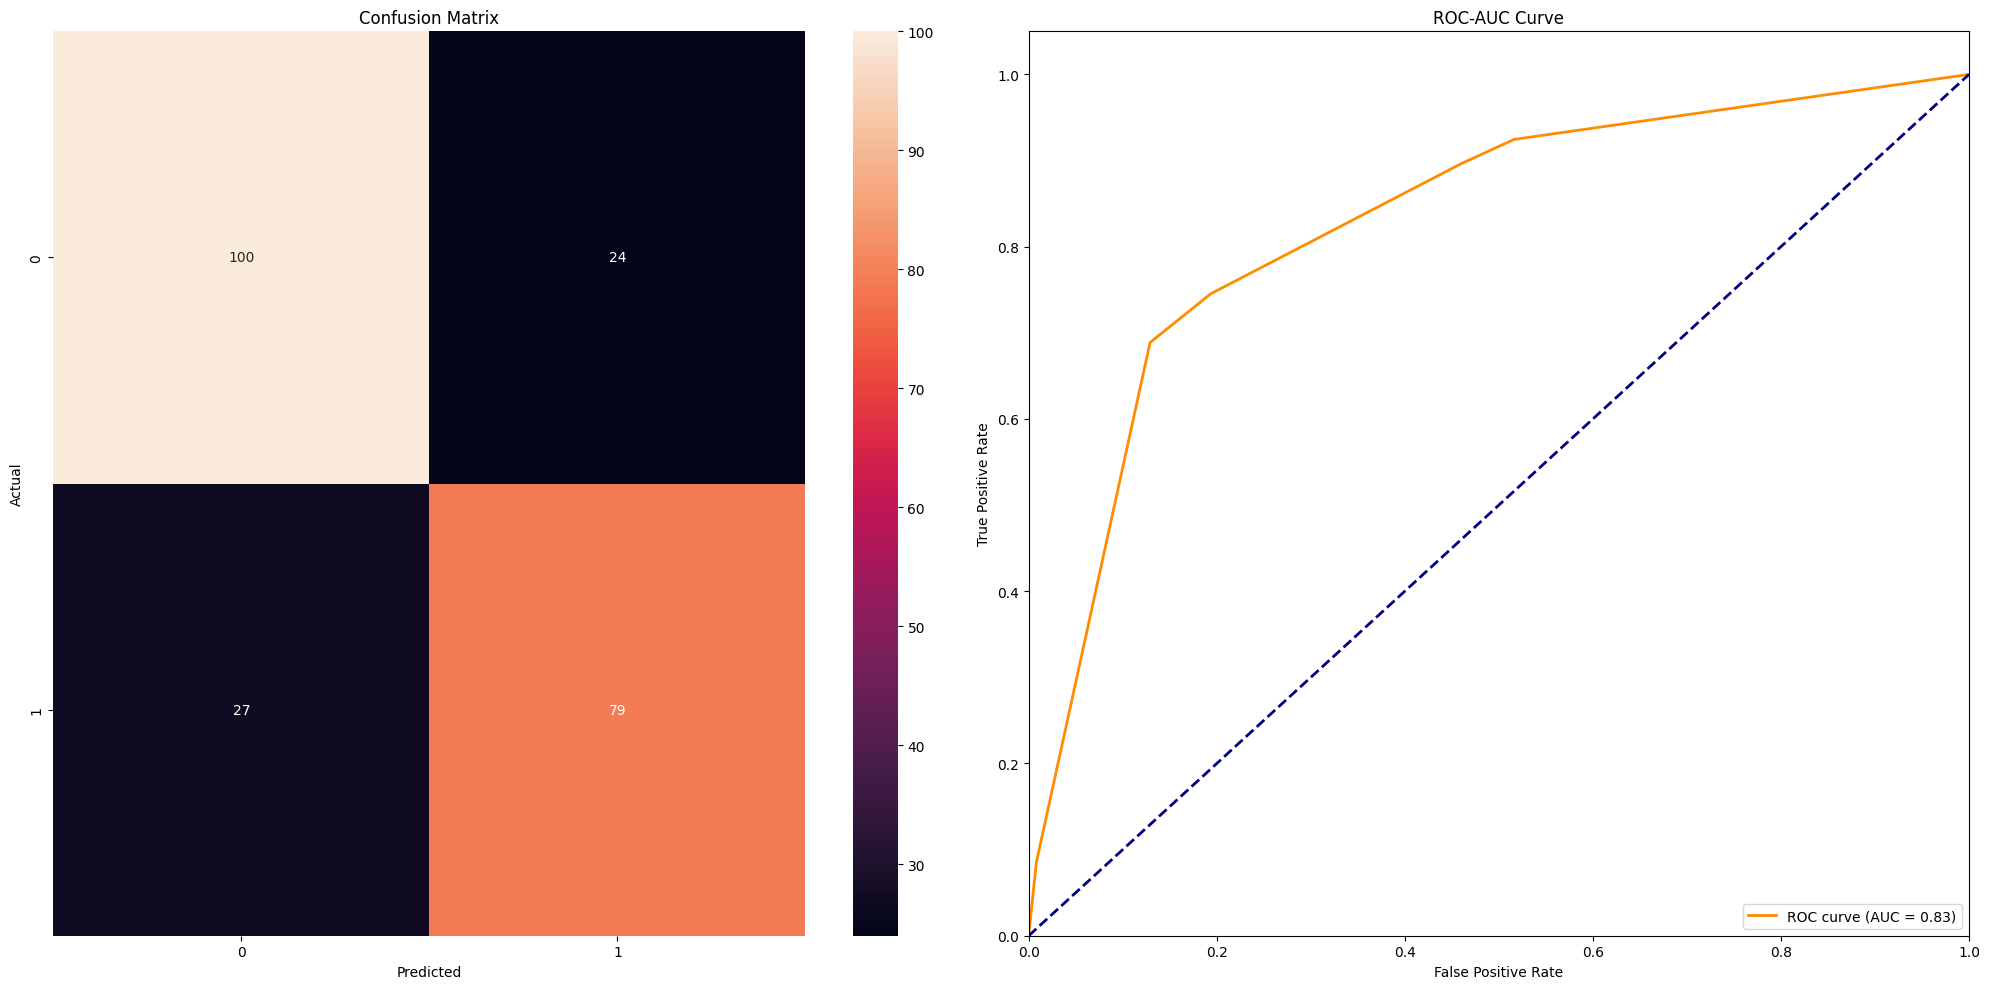

In [13]:
results_dt = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'dt')

print("\nBest Parameters:", results_dt['best_parameters'])
print("\nBest Cross-validation Score:", results_dt['best_score'])
print("\nFeature Importances:", results_dt['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_dt['classification_report'])

joblib.dump(results_dt['best_model'], 'best_dt_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effe


Best Parameters: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 200}

Best Cross-validation Score: 0.8344304503730005

Feature Importances: {'AAC_A': 0.0, 'AAC_C': 0.012270542193921893, 'AAC_D': 0.05328064616131729, 'AAC_E': 0.05837595750467783, 'AAC_F': 0.025705257389431076, 'AAC_G': 0.03370981494830229, 'AAC_H': 0.011121482679640644, 'AAC_I': 0.06985880980316411, 'AAC_K': 0.27924391384165104, 'AAC_L': 0.0, 'AAC_M': 0.04499137979694968, 'AAC_N': 0.02040742291446367, 'AAC_P': 0.007677697687665643, 'AAC_Q': 0.01154824000844742, 'AAC_R': 0.29273089664749175, 'AAC_S': 0.007899397973354086, 'AAC_T': 0.011981206468721119, 'AAC_V': 0.04010126065917981, 'AAC_W': 0.019096073321620617, 'AAC_Y': 0.0}

Classification Report:

===== Classification Performance Report =====

Per-Class Performance:
    precision   recall f1-score  support
0.0   0.81343  0.87903  0.84496    124.0
1.0   0.84375  0.76415  0.80198    106.0

Overall Performance:
             precision   recall f1-score  sup

['best_ab_model.pkl']

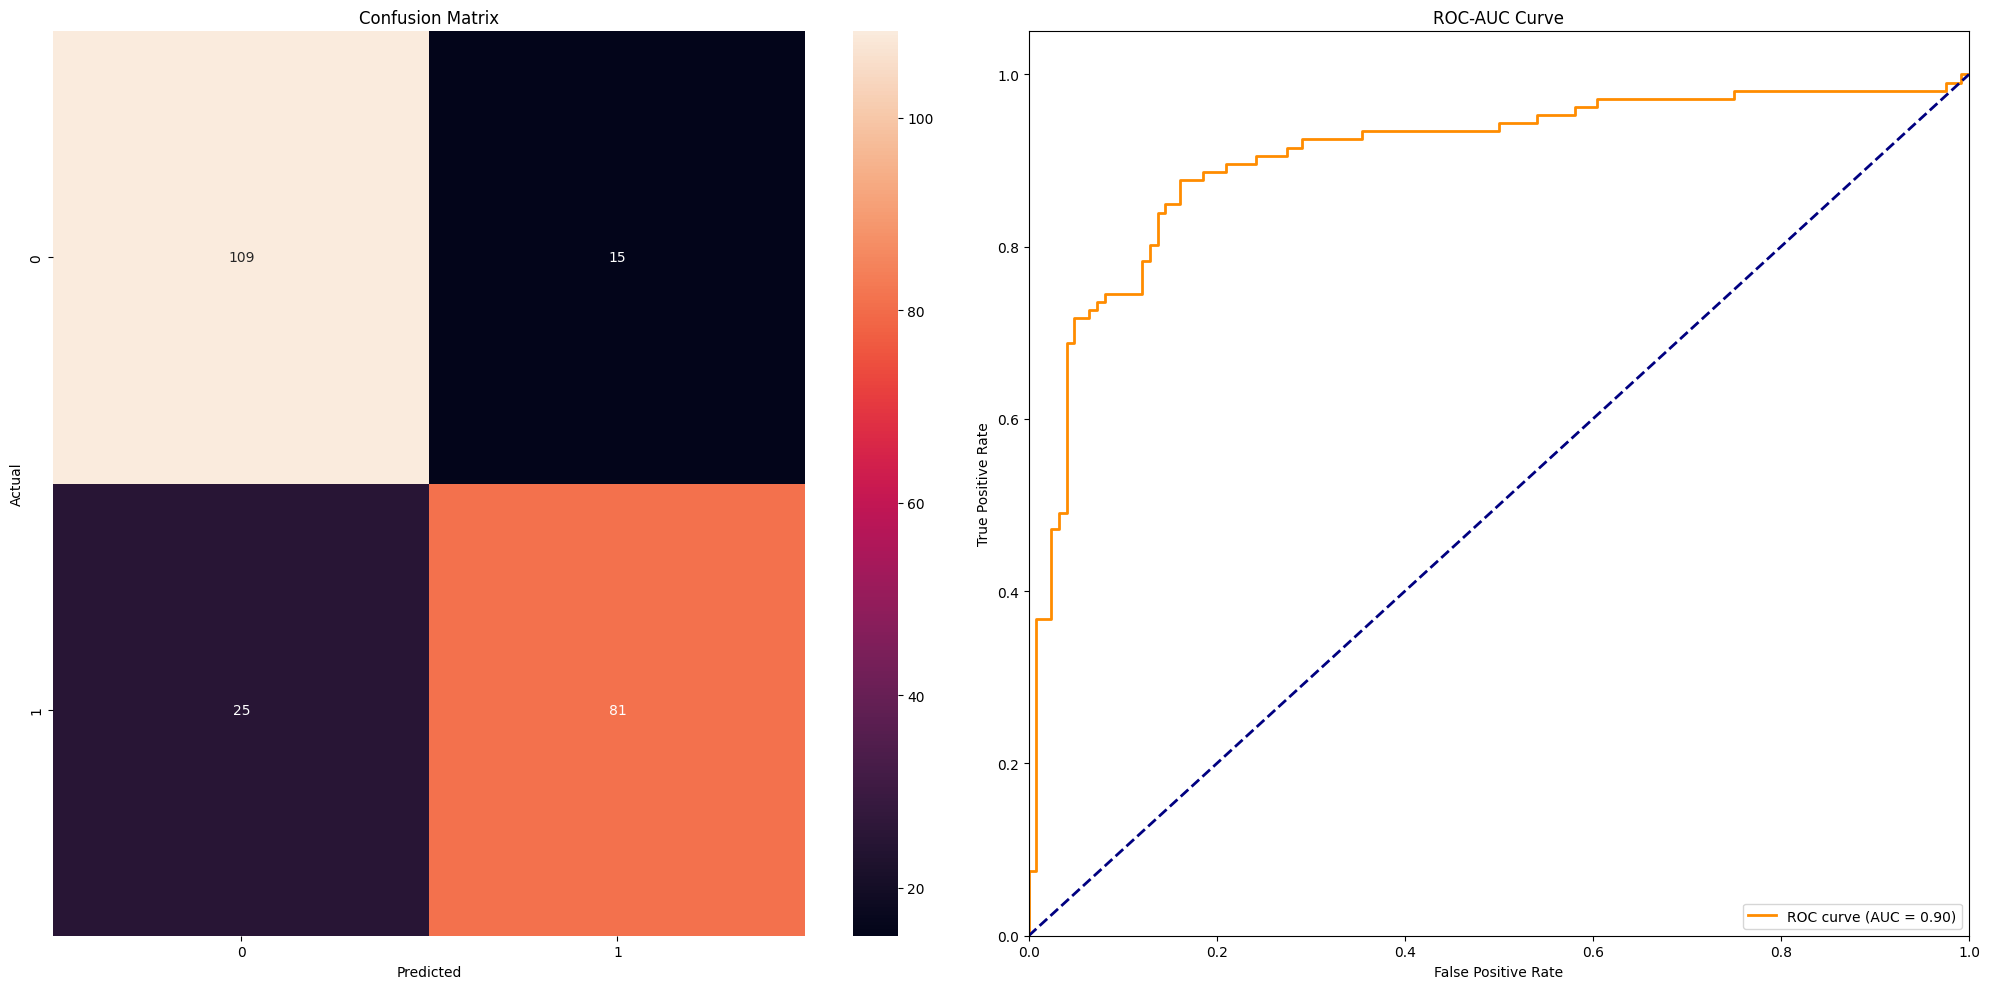

In [14]:
results_ab = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'ab')

print("\nBest Parameters:", results_ab['best_parameters'])
print("\nBest Cross-validation Score:", results_ab['best_score'])
print("\nFeature Importances:", results_ab['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_ab['classification_report'])

joblib.dump(results_ab['best_model'], 'best_ab_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 100 candidates, totalling 500 fits


/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Parameters: {'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 8, 'boosting_type': 'Plain', 'bagging_temperature': 0}

Best Cross-validation Score: 0.8840094371980541

Feature Importances: {'AAC_A': 4.10002161377688, 'AAC_C': 2.9010645393513634, 'AAC_D': 5.581325328063794, 'AAC_E': 5.7066463154194045, 'AAC_F': 4.74484181572521, 'AAC_G': 5.959269251961471, 'AAC_H': 3.1824383149600957, 'AAC_I': 5.142950307934029, 'AAC_K': 6.637006999815654, 'AAC_L': 3.5986893312897523, 'AAC_M': 3.3204489382768845, 'AAC_N': 3.4865860262047548, 'AAC_P': 5.393705425229101, 'AAC_Q': 3.790014854424948, 'AAC_R': 15.550501047908817, 'AAC_S': 3.9121834817075842, 'AAC_T': 3.291593766040255, 'AAC_V': 6.752479327116988, 'AAC_W': 3.1945456338515608, 'AAC_Y': 3.753687680941474}

Classification Report:

===== Classification Performance Report =====

Per-Class Performance:
    precision   recall f1-score  support
0.0   0.86822  0.90323  0.88538    124.0
1.0   0.88119  0.83962  0.85990    106.0



['best_cb_model.pkl']

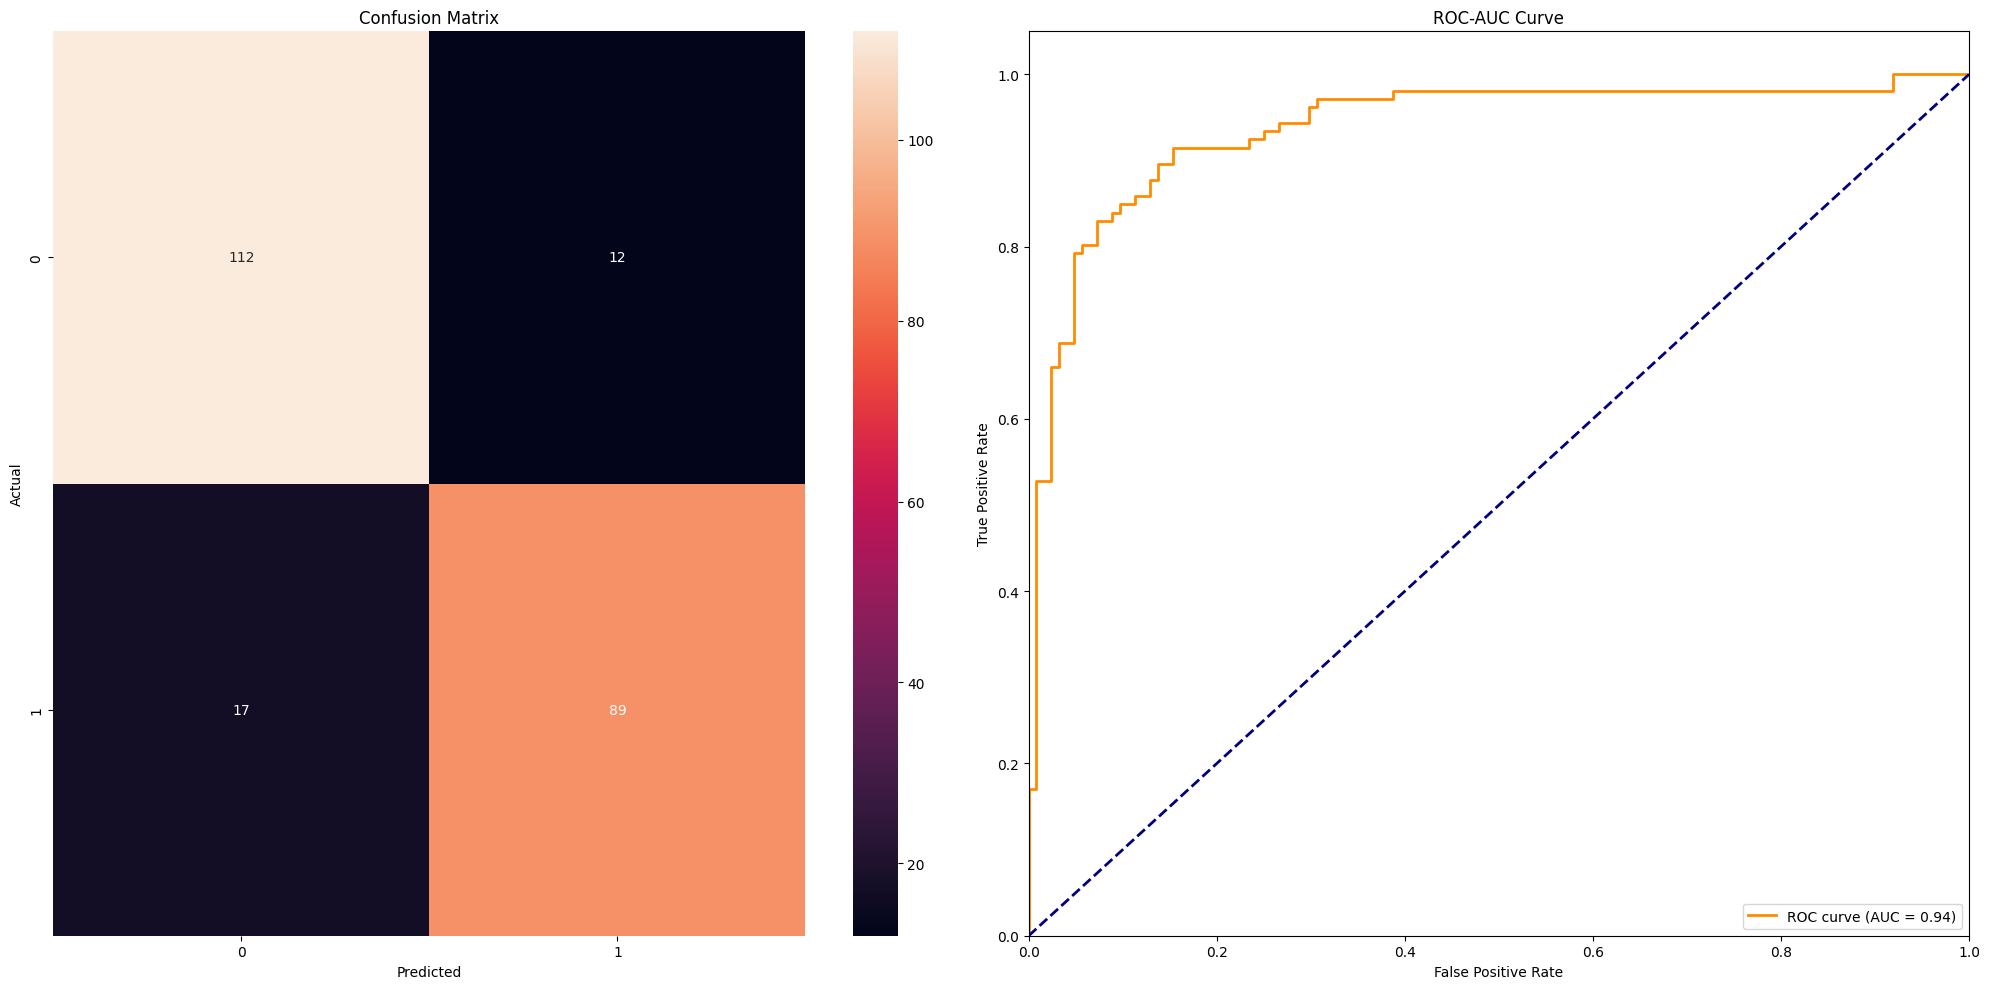

In [15]:
results_cb = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'cb')

print("\nBest Parameters:", results_cb['best_parameters'])
print("\nBest Cross-validation Score:", results_cb['best_score'])
print("\nFeature Importances:", results_cb['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_cb['classification_report'])

joblib.dump(results_cb['best_model'], 'best_cb_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 100 candidates, totalling 500 fits


/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 30, 'criterion': 'gini', 'class_weight': None}

Best Cross-validation Score: 0.8796337870249678

Feature Importances: {'AAC_A': 0.02607574839384441, 'AAC_C': 0.022383183652091465, 'AAC_D': 0.06065087843105302, 'AAC_E': 0.06866666995623609, 'AAC_F': 0.035094565918739, 'AAC_G': 0.039494239447332526, 'AAC_H': 0.022267192700633424, 'AAC_I': 0.047932629732091614, 'AAC_K': 0.0841029754926383, 'AAC_L': 0.03152858375186896, 'AAC_M': 0.03485326132278638, 'AAC_N': 0.039639183524170604, 'AAC_P': 0.03930333393446132, 'AAC_Q': 0.022924188136992655, 'AAC_R': 0.23062430557500907, 'AAC_S': 0.023505733119982858, 'AAC_T': 0.033082999510213255, 'AAC_V': 0.08594995169562121, 'AAC_W': 0.028641749717045382, 'AAC_Y': 0.02327862598718844}

Classification Report:

===== Classification Performance Report =====

Per-Class Performance:
    precision   recall f1-score  support
0.0   0.86719  0.8

['best_ert_model.pkl']

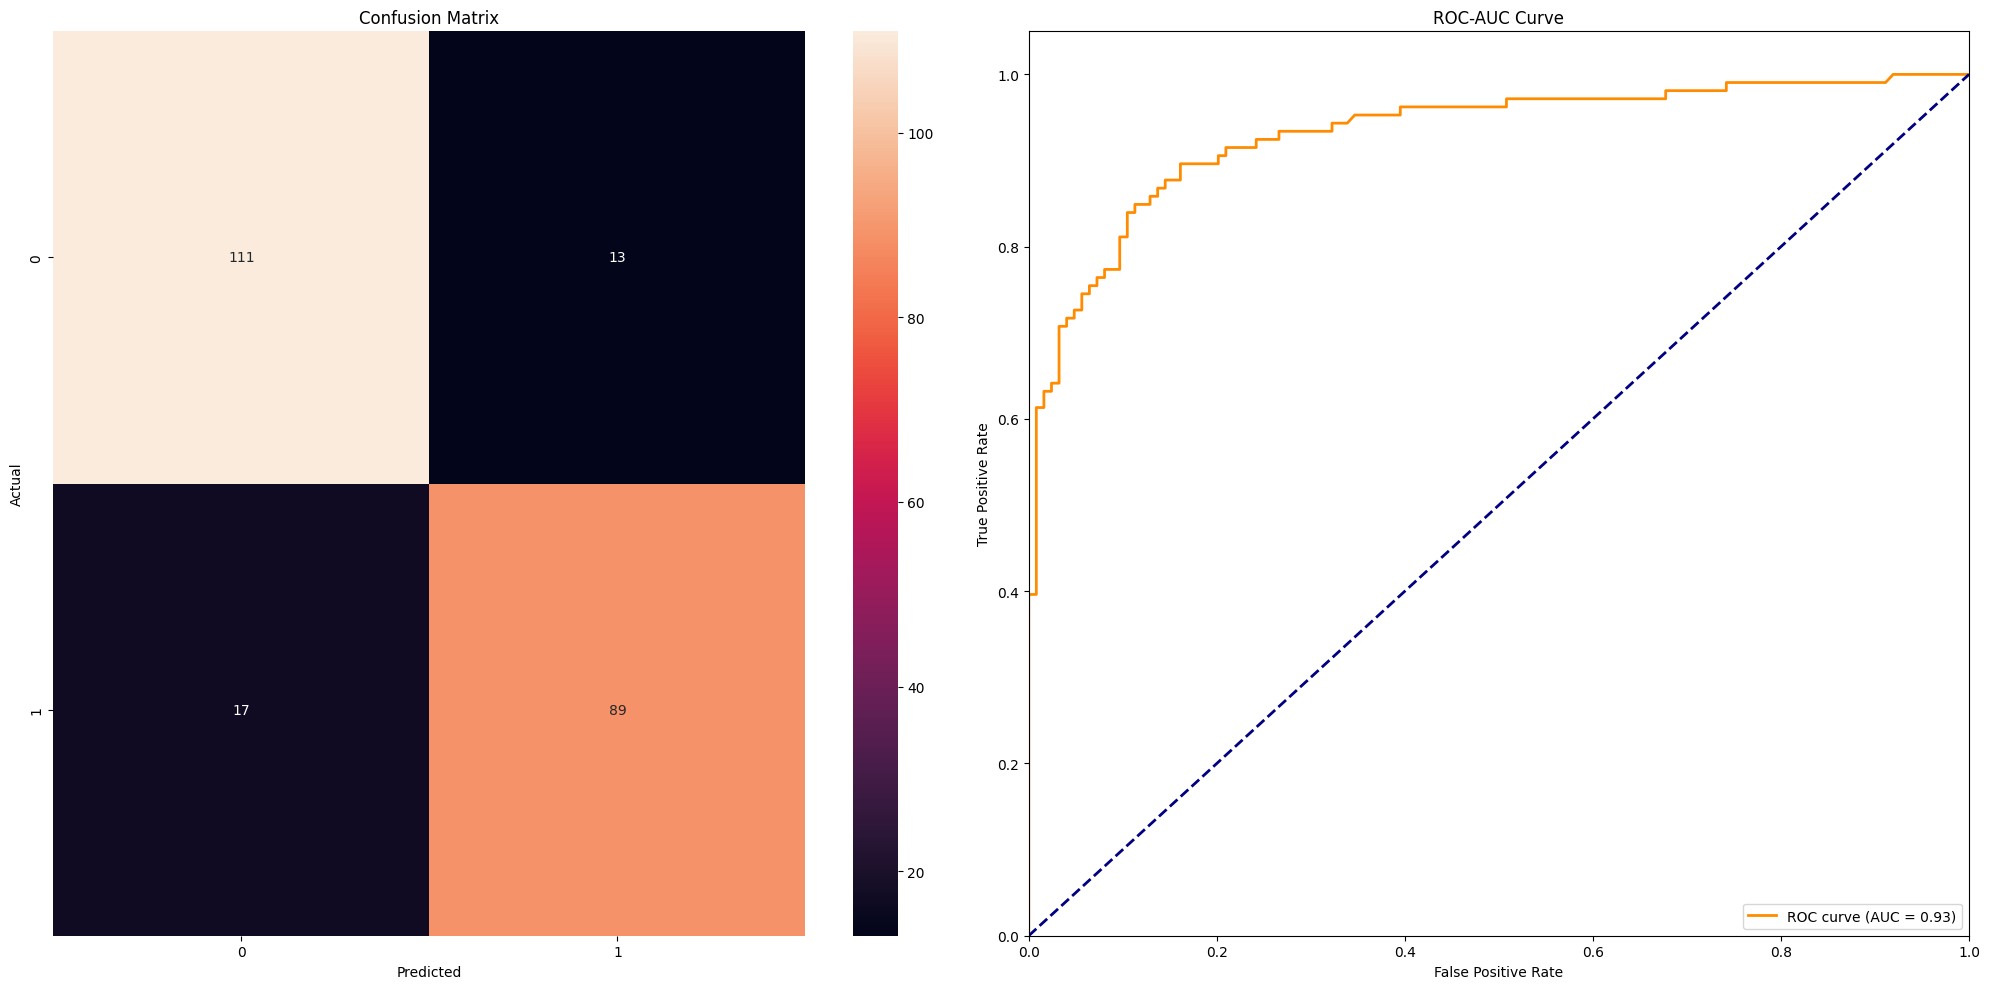

In [16]:
results_ert = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'ert')

print("\nBest Parameters:", results_ert['best_parameters'])
print("\nBest Cross-validation Score:", results_ert['best_score'])
print("\nFeature Importances:", results_ert['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_ert['classification_report'])

joblib.dump(results_ert['best_model'], 'best_ert_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters: {'subsample': 0.7, 'n_estimators': 500, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.05, 'criterion': 'friedman_mse'}

Best Cross-validation Score: 0.8903169867893925

Feature Importances: {'AAC_A': 0.03212015887272767, 'AAC_C': 0.031320465112809684, 'AAC_D': 0.05140341283981465, 'AAC_E': 0.05289854287293188, 'AAC_F': 0.03305925657503494, 'AAC_G': 0.04351003632758567, 'AAC_H': 0.02781382804234091, 'AAC_I': 0.036290241700590045, 'AAC_K': 0.11633877772260284, 'AAC_L': 0.033448524534565004, 'AAC_M': 0.019466320028562956, 'AAC_N': 0.025559870948556662, 'AAC_P': 0.05429255579356361, 'AAC_Q': 0.0243786010100451, 'AAC_R': 0.2581169145546082, 'AAC_S': 0.0269546417475405, 'AAC_T': 0.037896638527534804, 'AAC_V': 0.057481120099216444, 'AAC_W': 0.02040285260892499, 'AAC_Y': 0.017247240080443253}

Classification Report:

===== Classification Performance Report =====

Per-Class Performance:
    

['best_gb_model.pkl']

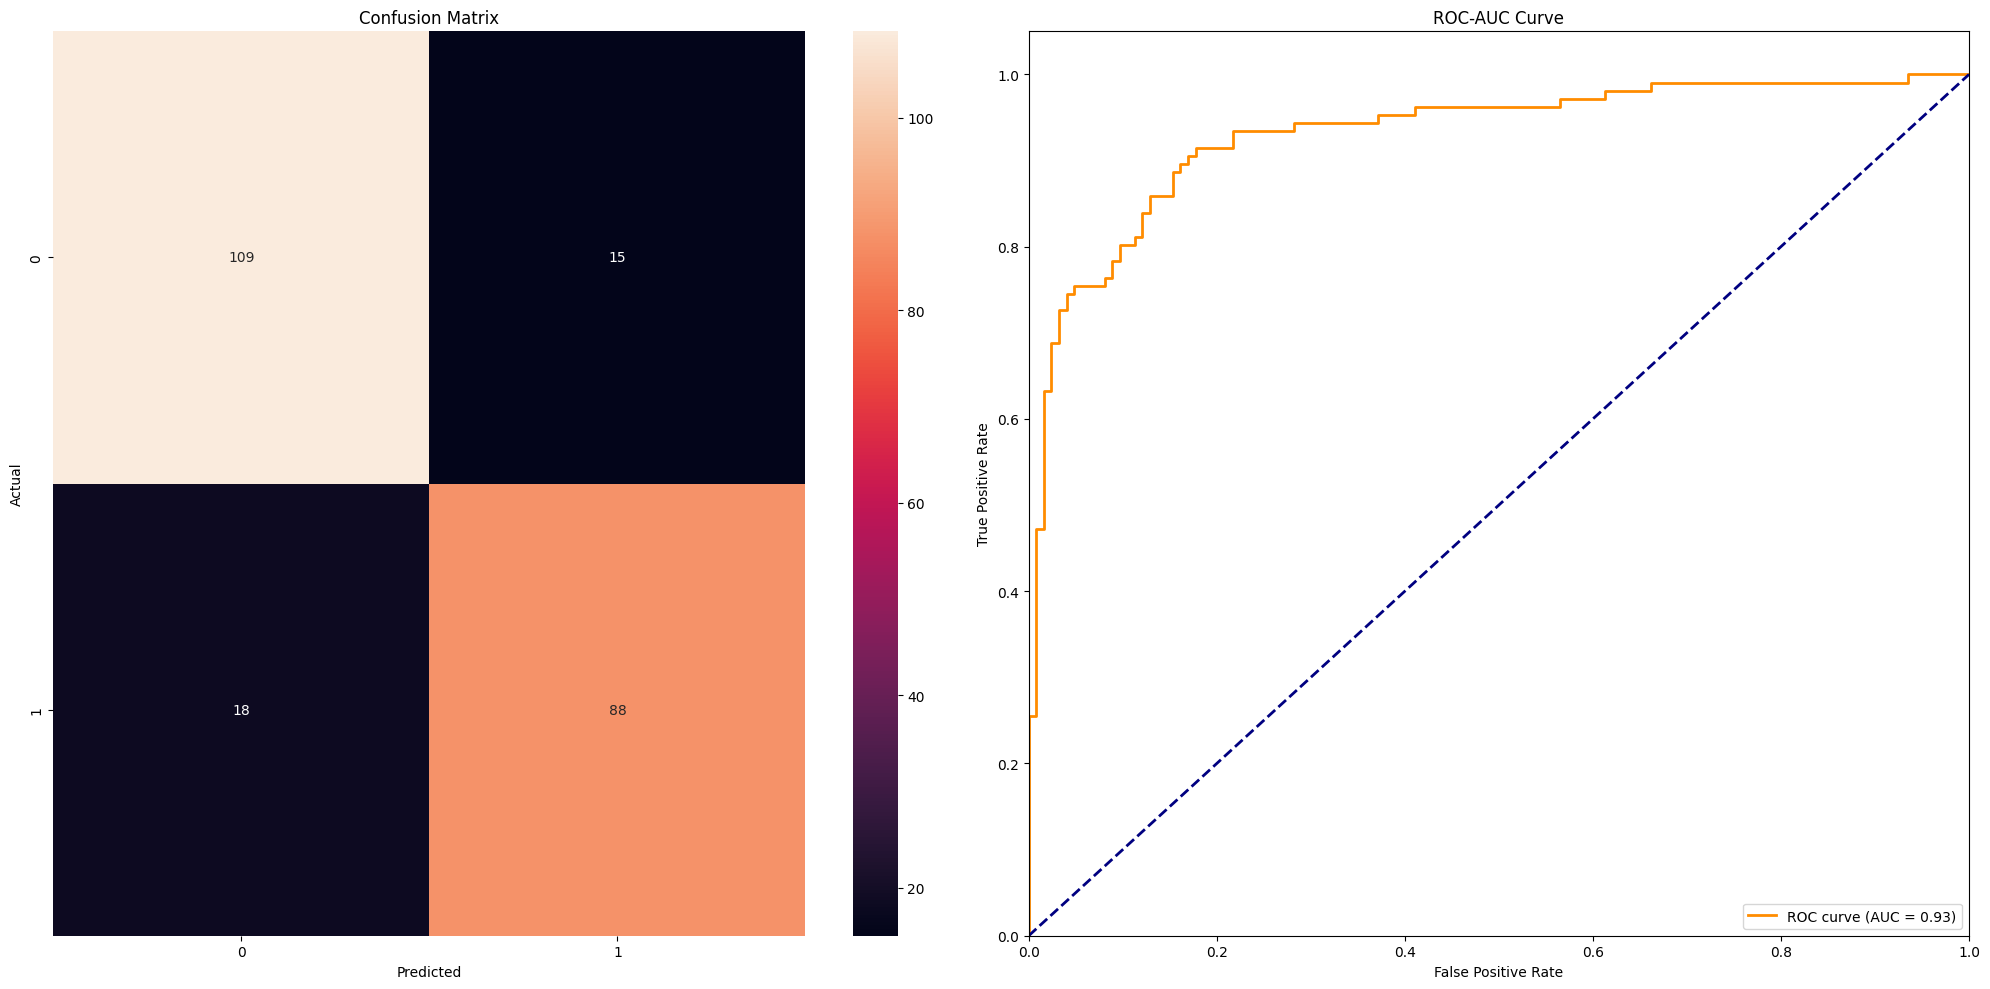

In [17]:
results_gb = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'gb')

print("\nBest Parameters:", results_gb['best_parameters'])
print("\nBest Cross-validation Score:", results_gb['best_score'])
print("\nFeature Importances:", results_gb['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_gb['classification_report'])

joblib.dump(results_gb['best_model'], 'best_gb_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=100. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/soulangel443/.local/share/mise/installs/python/3.12.6/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.war


Best Parameters: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best Cross-validation Score: 0.8922241526997471

Feature Importances: {'AAC_A': 164, 'AAC_C': 95, 'AAC_D': 117, 'AAC_E': 99, 'AAC_F': 130, 'AAC_G': 215, 'AAC_H': 102, 'AAC_I': 171, 'AAC_K': 205, 'AAC_L': 150, 'AAC_M': 68, 'AAC_N': 105, 'AAC_P': 177, 'AAC_Q': 112, 'AAC_R': 287, 'AAC_S': 169, 'AAC_T': 148, 'AAC_V': 165, 'AAC_W': 75, 'AAC_Y': 77}

Classification Report:

===== Classification Performance Report =====

Per-Class Performance:
    precision   recall f1-score  support
0.0   0.84091  0.89516  0.86719    124.0
1.0   0.86735  0.80189  0.83333    106.0

Overall Performance:
             precision   recall f1-score  support
macro avg      0.85413  0.84852  0.85026    230.0
weighted avg   0.85309  0.85217  0.85159    230.0

Accuracy: 0.852


['best_lgbm_model.pkl']

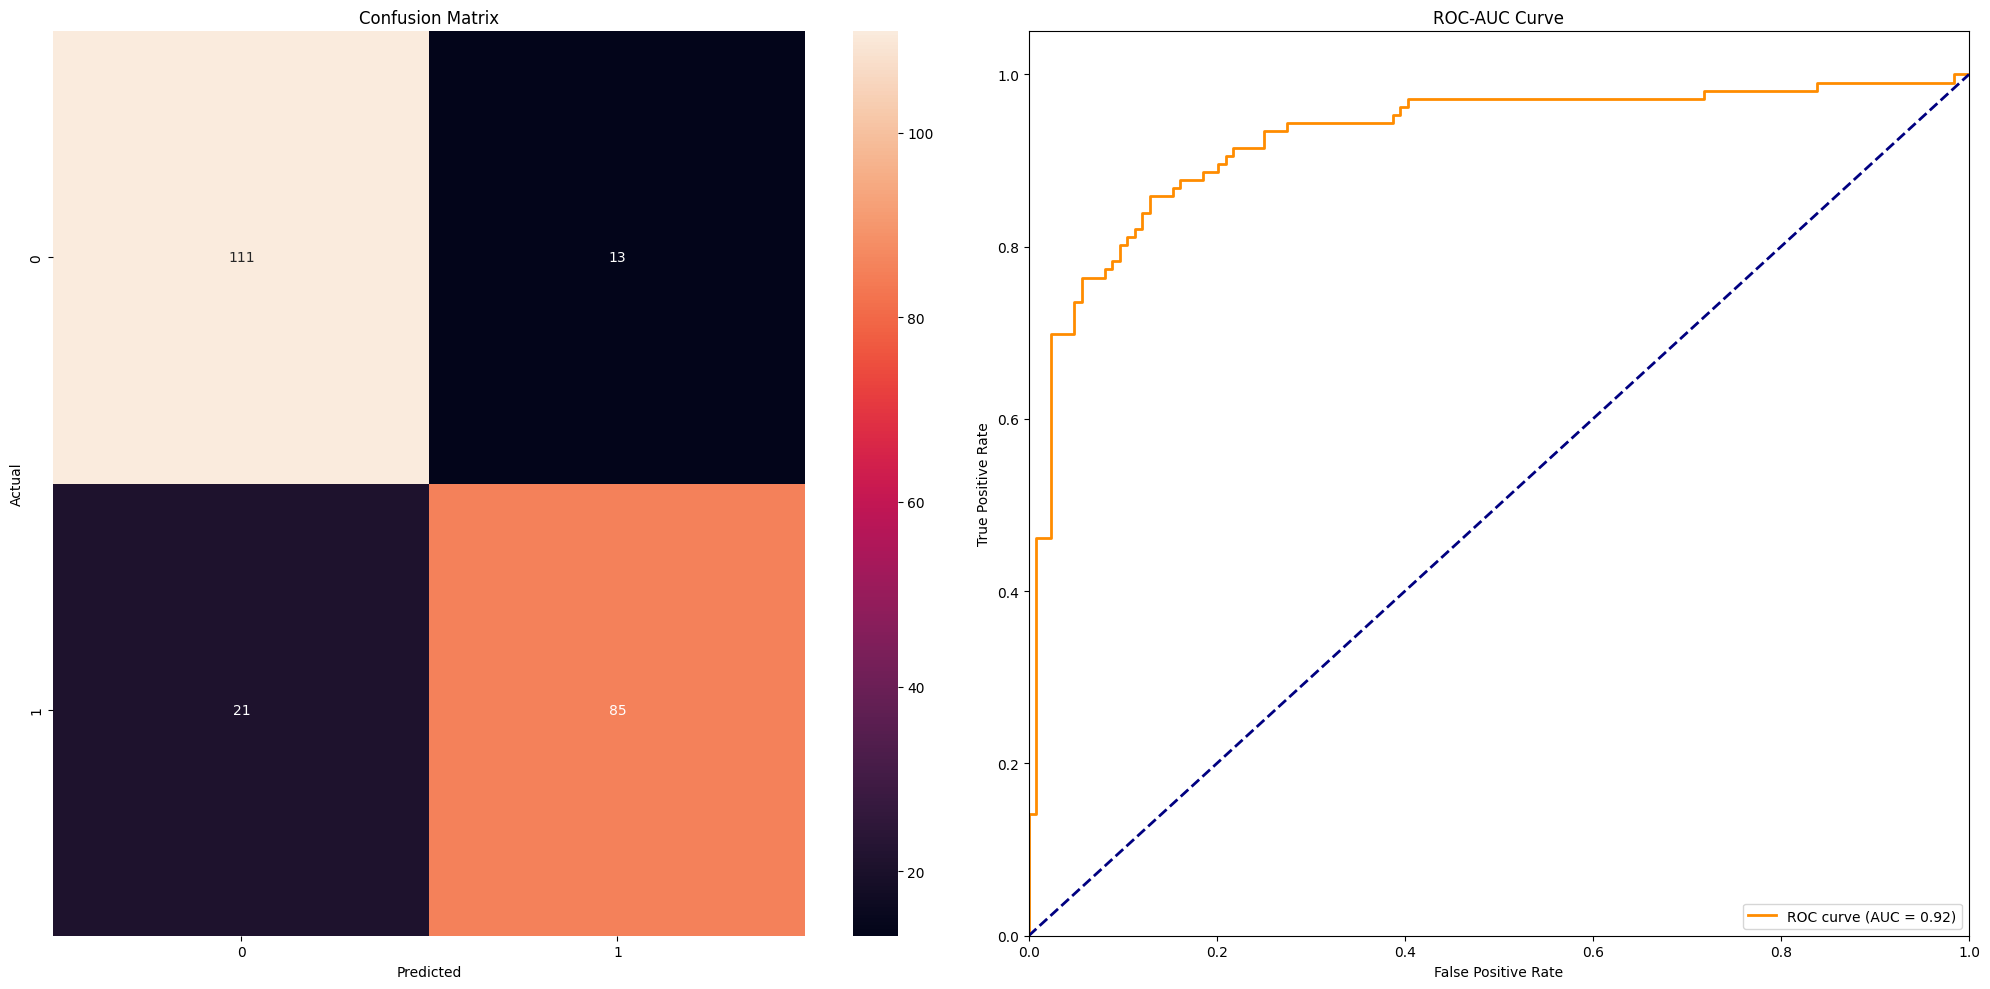

In [18]:
param_grid_lite = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50],
    'max_depth': [5, 10],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

results_lgbm = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'lgbm', custom_param_grid=param_grid_lite)

print("\nBest Parameters:", results_lgbm['best_parameters'])
print("\nBest Cross-validation Score:", results_lgbm['best_score'])
print("\nFeature Importances:", results_lgbm['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_lgbm['classification_report'])

joblib.dump(results_lgbm['best_model'], 'best_lgbm_model.pkl')

In [ ]:
xgb_light_grid = {'n_estimators': [100, 350],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 7],
            'gamma': [0, 0.1, 0.3],
            'subsample': [0.7, 0.9],
            'colsample_bytree': [0.7, 0.9],
            'reg_alpha': [0, 0.1, 1.0],
            'booster': ['gbtree', 'dart']}

results_xgb = cs.optimize_classifier(X_train, X_test, y_train, y_test, 'xgb', custom_param_grid=xgb_light_grid)

print("\nBest Parameters:", results_xgb['best_parameters'])
print("\nBest Cross-validation Score:", results_xgb['best_score'])
print("\nFeature Importances:", results_xgb['feature_importances'])
print("\nClassification Report:")
pretty_print_classification_report(results_xgb['classification_report'])

joblib.dump(results_xgb['best_model'], 'best_xgb_model.pkl')

n_jobs = 2
Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [ ]:
from plyer import notification  # For desktop notifications
from pushbullet import Pushbullet  # For phone notifications

# Your Pushbullet access token (replace with your own)
PUSHBULLET_ACCESS_TOKEN = "o.S0IB1IH91KefXiNILKKvtBY9T5os2hEu"

# Initialize Pushbullet with your token
pb = Pushbullet(PUSHBULLET_ACCESS_TOKEN)

# Your existing desktop notification
notification.notify(
    title="Notebook Complete",
    message="Your AAC dataset training notebook has finished running!",
    timeout=15  # Notification stays for 15 seconds on desktop
)

# Send the same notification to your phone via Pushbullet
pb.push_note(
    title="Notebook Complete",
    body="Your AAC dataset training notebook has finished running!"
)